In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.27767328/cloudy_fits/'

Species names

In [5]:
ion_list = ['HI', 'HeI', 'CII', 'CIII', 'CIV', 'NII', 'NIII', 'NIV', 'NV',
            'OII', 'OIII', 'OIV', 'OV', 'OVI', 'SiII', 'SiIII', 'SiIV',
            'MgII', 'MgX', 'NeV', 'NeVI', 'NeVIII', 'SIV', 'SV', 'SVI']

Specify density/metallicity grid

In [6]:
log_metals_arr = [-2.6,-2.4,-2.2,-2.0,-1.8,-1.6,-1.4,-1.2,-1.0 ,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0]
log_hdens_arr = [-4.8,-4.4,-4.2,-4.0,-3.8,-3.6,-3.4,-3.2,-3.0,-2.8,-2.6,-2.4,-2.2,-2.0,-1.8,-1.6]
logT_arr = np.arange(4.00, 6.01, 0.01)

Load grids

In [7]:
pkl_file = open(rootdir+'TDP_grid.pkl', 'rb')
logX_dict_TDP_samples = pickle.load(pkl_file)
pkl_file.close()

Set up the 3D grid across metallicity, density, and temperature

In [8]:
logX_dict_TDP_interp = {}

for ion in ion_list:
    logX_dict_TDP_interp[ion] = RegularGridInterpolator((log_metals_arr, log_hdens_arr, logT_arr), 
                                                     logX_dict_TDP_samples[ion])

# Make diagnostics

In [9]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            #'CII':'<13.4',
            #'CIII':'12.9, -0.2, +0.1',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',}
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            #'SiII':'<14.0',
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',
            #'FeII':'<11.8',}

In [10]:
gen_logN_ratio_str(logN_dict['OIV'], logN_dict['OIII'])

'0.63, -0.09, 0.09'

In [11]:
logN_ratio_dict = {'OIV/OIII': '0.63, -0.09, 0.09',
                   'OVI/OIV': '0.25, -0.11, 0.11'
                  }

## OIII, OIV, OVI

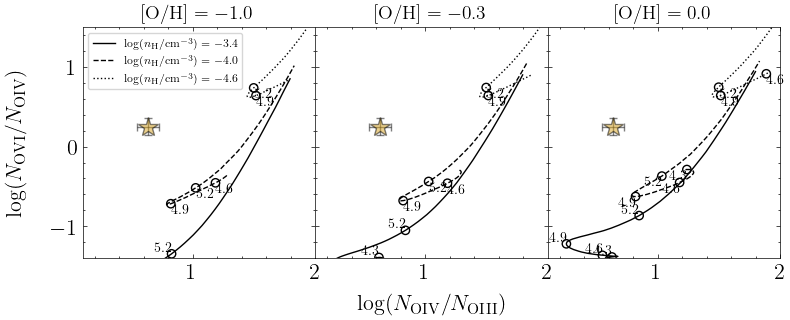

In [12]:
fig, axes = plt.subplots(1,3,figsize=(3*3,3), sharex=True, sharey=True)

# Plot measurements

scat_logN_ratio(axes[0], 'OIV/OIII', 'OVI/OIV', logN_ratio_dict)
axes[0].set_title(r'$\mathrm{[O/H]}=-1.0$', fontsize=14)

scat_logN_ratio(axes[1], 'OIV/OIII', 'OVI/OIV', logN_ratio_dict)
axes[1].set_title(r'$\mathrm{[O/H]}=-0.3$', fontsize=14)

scat_logN_ratio(axes[2], 'OIV/OIII', 'OVI/OIV', logN_ratio_dict)
axes[2].set_title(r'$\mathrm{[O/H]}=0.0$', fontsize=14)

ax_label = fig.add_subplot(111, frameon=False)
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$\log(N_\mathrm{OIV}/N_\mathrm{OIII})$', labelpad=25)
ax_label.set_ylabel(r'$\log(N_\mathrm{OVI}/N_\mathrm{OIV})$', labelpad=40)

plt.subplots_adjust(wspace=0, hspace=0.0)

# Plot tracks
# metals = -1.0

plot_logN_ratio_track(axes[0], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      -1.0, -3.4, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[0], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      -1.0, -4.0, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[0], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      -1.0, -4.6, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      ':', 'left', 'top')

axes[0].legend(fontsize=8)

# metals = -0.3

plot_logN_ratio_track(axes[1], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      -0.3, -3.4, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[1], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      -0.3, -4.0, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[1], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      -0.3, -4.6, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      ':', 'left', 'top')

# metals = 0.0

plot_logN_ratio_track(axes[2], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.0, -3.4, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[2], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.0, -4.0, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '--', 'right', 'top')

plot_logN_ratio_track(axes[2], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.0, -4.6, 
                      4.0, 5.5, .01,
                      4.0, 5.5, .3,
                      0.1, 2.0, -1.4, 1.5,
                      ':', 'left', 'top')

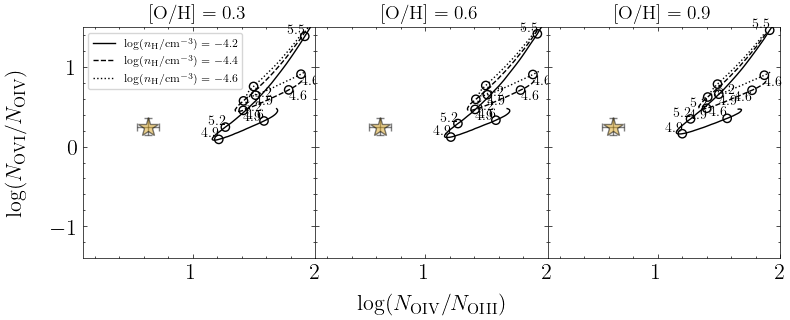

In [13]:
fig, axes = plt.subplots(1,3,figsize=(3*3,3), sharex=True, sharey=True)

# Plot measurements

scat_logN_ratio(axes[0], 'OIV/OIII', 'OVI/OIV', logN_ratio_dict)
axes[0].set_title(r'$\mathrm{[O/H]}=0.3$', fontsize=14)

scat_logN_ratio(axes[1], 'OIV/OIII', 'OVI/OIV', logN_ratio_dict)
axes[1].set_title(r'$\mathrm{[O/H]}=0.6$', fontsize=14)

scat_logN_ratio(axes[2], 'OIV/OIII', 'OVI/OIV', logN_ratio_dict)
axes[2].set_title(r'$\mathrm{[O/H]}=0.9$', fontsize=14)

ax_label = fig.add_subplot(111, frameon=False)
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$\log(N_\mathrm{OIV}/N_\mathrm{OIII})$', labelpad=25)
ax_label.set_ylabel(r'$\log(N_\mathrm{OVI}/N_\mathrm{OIV})$', labelpad=40)

plt.subplots_adjust(wspace=0, hspace=0.0)

# Plot tracks
# metals = -1.0

plot_logN_ratio_track(axes[0], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.3, -4.2, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[0], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.3, -4.4, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[0], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.3, -4.6, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      ':', 'left', 'top')

axes[0].legend(fontsize=8)

# metals = -0.3

plot_logN_ratio_track(axes[1], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.6, -4.2, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[1], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.6, -4.4, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[1], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.6, -4.6, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      ':', 'left', 'top')

# metals = 0.0

plot_logN_ratio_track(axes[2], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.9, -4.2, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[2], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.9, -4.4, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      '--', 'right', 'top')

plot_logN_ratio_track(axes[2], 'OIII', 'OIV', 'OIV', 'OVI', logX_dict_TDP_interp,
                      0.9, -4.6, 
                      4.0, 6.0, .01,
                      4.0, 6.0, .3,
                      0.1, 2.0, -1.4, 1.5,
                      ':', 'left', 'top')

## HI

Text(0, 0.5, '$\\log(N_\\mathrm{HI}/\\mathrm{cm}^{-2})$')

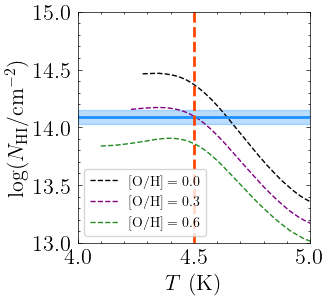

In [14]:
fig, ax = plt.subplots(1, figsize=(3,3))

logT_filt, logN_HI_filt = get_logN_HI('OIII', 13.82, 0, -4.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='black', linestyle='--', label=r'$\mathrm{[O/H]}=0.0$')

logT_filt, logN_HI_filt = get_logN_HI('OIII', 13.82, 0.3, -4.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='purple', linestyle='--', label=r'$\mathrm{[O/H]}=0.3$')

logT_filt, logN_HI_filt = get_logN_HI('OIII', 13.82, 0.6, -4.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='forestgreen', linestyle='--', label=r'$\mathrm{[O/H]}=0.6$')

ax.axhline(14.09, color='dodgerblue', lw=2)
ax.axhspan(14.03,14.15, color='dodgerblue',alpha=.3)
ax.axvline(4.5, color='orangered', lw=2, linestyle='--')

ax.set_xlim(4.0, 5.0)
ax.set_ylim(13, 15)

ax.legend(fontsize=10, loc='lower left')
ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\log(N_\mathrm{HI}/\mathrm{cm}^{-2})$')

# Fit column densities - oxygen only

In [15]:
def log_prior_1(log_metals, log_hdens, logT, logN_HI):
    
    if log_metals_arr[0]<log_metals<log_metals_arr[-1]:
        if log_hdens_arr[0]<log_hdens<log_hdens_arr[-1]:
            if 4.0<logT<5.5:
                
                # measured HI - use as upper limit
                logN_HI_obs = 14.09
                
                if 12.0<logN_HI<logN_HI_obs: # Underpredict HI
                    return np.log(10**log_hdens) + np.log(10**logT) + np.log(10**logN_HI)
                else:
                    return -np.inf
            else:
                return -np.inf
        else:
            return -np.inf
    else:
        return -np.inf

In [16]:
def log_likelihood_1(log_metals, log_hdens, logT, logN_HI, logN_dict, logX_dict_TDP_interp):
        
    ll = 0
    
    for ion in list(logN_dict.keys()):
        
        y_bar = predict_col_dens_TDP(ion, log_metals, log_hdens, logT, logN_HI, logX_dict_TDP_interp)
        logN_str = logN_dict[ion]
        
        ll += compute_ll(logN_str, y_bar)

    # Compute chi-square
    return ll

In [17]:
def log_probability_1(params, logN_dict, logX_dict_TDP_interp):
    
    log_metals, log_hdens, logT, logN_HI = params
    
    lp = log_prior_1(log_metals,log_hdens,logT,logN_HI)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp+log_likelihood_1(log_metals,log_hdens,logT,logN_HI,logN_dict,logX_dict_TDP_interp)

In [18]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            #'CII':'<13.4',
            #'CIII':'12.9, -0.2, +0.1',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'<13.82',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',}
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',}
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            #'SiII':'<14.0',
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [19]:
log_metals_test = 0.0
log_hdens_test = -4.3
logT_test = 5.0
logN_HI_test = 13.5

logN_test = predict_col_dens_model_TDP(logN_dict,log_metals_test,log_hdens_test,logT_test,logN_HI_test,logX_dict_TDP_interp)

(13.0, 15.0)

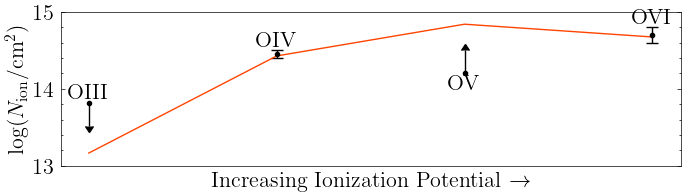

In [20]:
fig, ax = plt.subplots(1, figsize=(8,2))

plot_column_densities_obs(logN_dict, fig, ax,
                          gray_out = ['CII', 'CIII', 'CIV'])

ax.plot(np.arange(len(logN_dict)), logN_test, color='orangered')

ax.set_ylim(13,15)

In [21]:
pos = np.array([log_metals_test, log_hdens_test, logT_test, logN_HI_test]) + 1e-4 * np.random.randn(200, 4)
nwalkers, ndim = pos.shape

In [22]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability_1, args=(logN_dict,logX_dict_TDP_interp)
)

In [23]:
#sampler.run_mcmc(pos, 500, progress=True);

In [24]:
#flat_samples_1 = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_metals', 'log_hdens', 'logT', 'logN_HI'])
#flat_samples_1.to_csv(savedir+'TDP_1.csv', index=False)

flat_samples_1 = pd.read_csv(savedir+'TDP_1.csv')

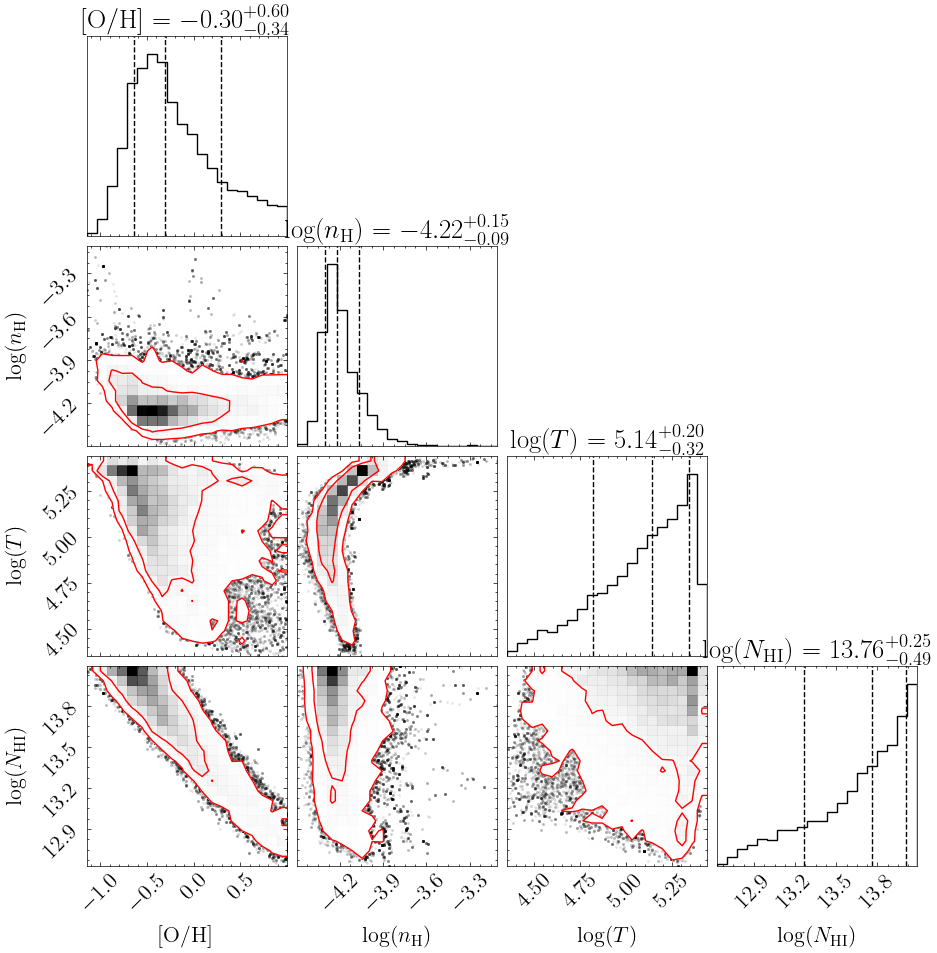

In [25]:
fig = corner.corner(
    flat_samples_1, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\mathrm{[O/H]}$', r'$\log(n_\mathrm{H})$', r'$\log(T)$', r'$\log(N_\mathrm{HI})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Make a plot

In [26]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            #'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',}
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',}
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            #'SiII':'<14.0',
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [27]:
p1_grid = np.array(flat_samples_1)

yb_med = np.zeros(len(logN_dict))
yb_lo = np.zeros(len(logN_dict))
yb_hi = np.zeros(len(logN_dict))

ctr = 0

for i in range(len(ion_species_dict)):
    
    ion = list(ion_species_dict.keys())[i]

    if ion in list(logN_dict.keys()):
        
        y_samples = predict_col_dens_TDP(ion,p1_grid[:,0],p1_grid[:,1],p1_grid[:,2],p1_grid[:,3],logX_dict_TDP_interp)

        yb_med[ctr] = np.median(y_samples)
        yb_lo[ctr] = np.percentile(y_samples, 16)
        yb_hi[ctr] = np.percentile(y_samples, 84)
        
        ctr += 1

(12.0, 15.7)

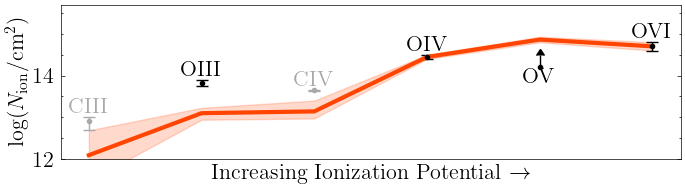

In [28]:
fig, ax = plt.subplots(1, figsize=(8,2))

plot_column_densities_obs(logN_dict, fig, ax,
                          gray_out = ['CII', 'CIII', 'CIV'])

ax.plot(np.arange(len(logN_dict)), yb_med, lw=3, color='orangered')
ax.fill_between(np.arange(len(logN_dict)), yb_lo, yb_hi, color='orangered', alpha=.2)

ax.set_ylim(12.0,15.7)

In [29]:
yb_med[2], yb_med[2]-yb_lo[2], yb_hi[2]-yb_med[2]

(13.138098935677547, 0.1691355371323482, 0.2597818102965004)

In [30]:
x1 = np.random.normal(13.14, 0.25, 1000)
x2 = np.random.normal(13.65, 0.01,1000)

In [31]:
np.nanmedian(np.log10(10**x2-10**x1)), np.nanstd(np.log10(10**x2-10**x1))

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_9677/843983262.py:1: RuntimeWarning: invalid value encountered in log10
  np.nanmedian(np.log10(10**x2-10**x1)), np.nanstd(np.log10(10**x2-10**x1))


(13.494707411263663, 0.16676531958694385)

# Fit column densities - HI + CIII + CIV + OIII

In [40]:
def log_prior_2(log_metals, log_hdens, logT, C_O):
    
    if log_metals_arr[0]<log_metals<log_metals_arr[-1] and -3<log_metals+C_O<1: #[C/H]
        if log_hdens_arr[0]<log_hdens<log_hdens_arr[-1]:
            if 4.0<logT<4.8: # Temperature limits based on HI linewidth
                return np.log(10**log_hdens) + np.log(10**logT)
            else:
                return -np.inf
        else:
            return -np.inf
    else:
        return -np.inf

In [41]:
def log_likelihood_2(log_metals, log_hdens, logT, C_O, logN_dict, logX_dict_TDP_interp):
    
    logN_HI_obs = 14.09 # Measured N(HI) to generate column densities
    
    ll = 0
    
    for ion in list(logN_dict.keys()):
        
        # Model side: prediction adjusted for elemental abundance
        elem = ion_species_dict[ion].split('+')[0]
        
        y_bar = predict_col_dens_TDP(ion, log_metals, log_hdens, logT, logN_HI_obs, logX_dict_TDP_interp)
        if elem == 'C':
            y_bar += C_O 
            
        # Data side: handle upper limits, lower limits, and measurements separately
        logN_str = logN_dict[ion]
        
        ll += compute_ll(logN_str, y_bar)

    return ll

In [42]:
def log_probability_2(params, logN_dict, logX_dict_TDP_interp):
    
    log_metals, log_hdens, logT, C_O = params
    
    lp = log_prior_2(log_metals,log_hdens,logT,C_O)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp+log_likelihood_2(log_metals,log_hdens,logT,C_O,logN_dict,logX_dict_TDP_interp)

In [44]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.5, -0.2, +0.2',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'<14.45',
            #'OV':'>14.2',
            'OVI':'<14.7',
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            'SiII':'<14.0',
            'SiIII':'<11.7',}
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [45]:
log_metals_test = -0.4
log_hdens_test = -3.6
logT_test = 4.7
C_O_test = -0.3
logN_HI_test = 14.09

logN_test = predict_col_dens_model_TDP(logN_dict,log_metals_test,log_hdens_test,logT_test,logN_HI_test,logX_dict_TDP_interp, C_O_test)

(12.0, 15.0)

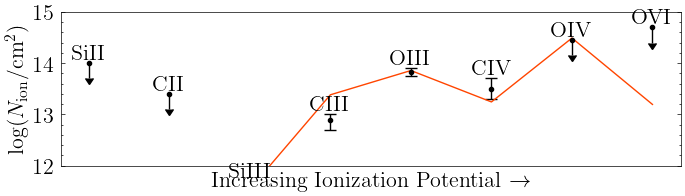

In [46]:
fig, ax = plt.subplots(1, figsize=(8,2))

plot_column_densities_obs(logN_dict, fig, ax)

ax.plot(np.arange(len(logN_dict)), logN_test, color='orangered')

ax.set_ylim(12,15.0)

In [38]:
pos = np.array([log_metals_test, log_hdens_test, logT_test, C_O_test]) + 1e-4 * np.random.randn(200, 4)
nwalkers, ndim = pos.shape

In [39]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability_2, args=(logN_dict,logX_dict_TDP_interp)
)

In [40]:
#sampler.run_mcmc(pos, 500, progress=True);

In [41]:
#flat_samples_2 = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_metals', 'log_hdens', 'logT', 'C_O'])
#flat_samples_2.to_csv(savedir+'TDP_2.csv', index=False)

flat_samples_2 = pd.read_csv(savedir+'TDP_2.csv')

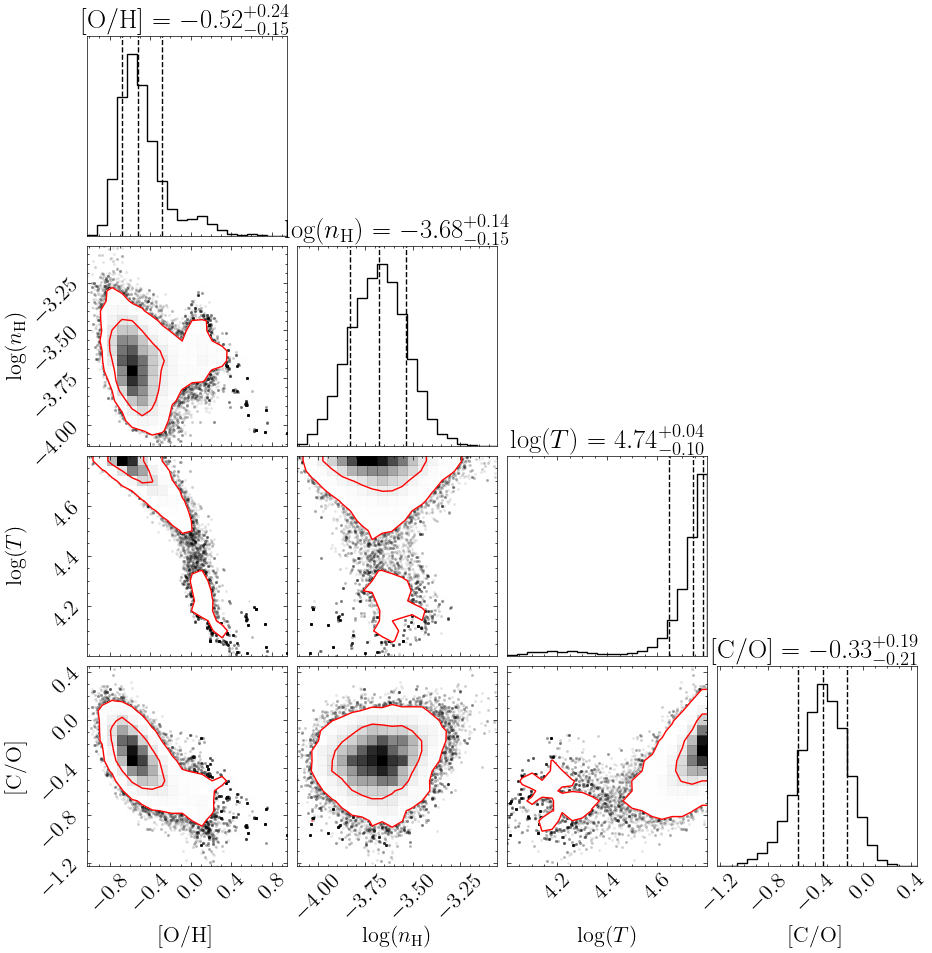

In [42]:
fig = corner.corner(
    flat_samples_2, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\mathrm{[O/H]}$', r'$\log(n_\mathrm{H})$', r'$\log(T)$', r'$\mathrm{[C/O]}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Make a plot

In [43]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.5, -0.2, +0.2',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',}
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            'SiII':'<14.0',
            'SiIII':'<11.7',}
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [44]:
p2_grid = np.array(flat_samples_2)

yb_med = np.zeros(len(logN_dict))
yb_lo = np.zeros(len(logN_dict))
yb_hi = np.zeros(len(logN_dict))

ctr = 0

for i in range(len(ion_species_dict)):
    
    ion = list(ion_species_dict.keys())[i]
    elem = ion_species_dict[ion].split('+')[0]
    
    if ion in list(logN_dict.keys()):
        
        y_samples = predict_col_dens_TDP(ion, p2_grid[:,0], p2_grid[:,1], p2_grid[:,2], 14.09, logX_dict_TDP_interp)
        if elem == 'C':
            y_samples += p2_grid[:,3]

        yb_med[ctr] = np.median(y_samples)
        yb_lo[ctr] = np.percentile(y_samples, 16)
        yb_hi[ctr] = np.percentile(y_samples, 84)
        
        ctr += 1

(10.8, 15.9)

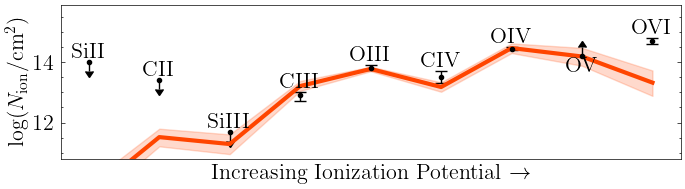

In [45]:
fig, ax = plt.subplots(1, figsize=(8,2))

plot_column_densities_obs(logN_dict, fig, ax)

ax.plot(np.arange(len(logN_dict)), yb_med, lw=3, color='orangered')
ax.fill_between(np.arange(len(logN_dict)), yb_lo, yb_hi, color='orangered', alpha=.2)

ax.set_ylim(10.8,15.9)

# Fit column densities - two-phase

In [12]:
def log_prior_3(log_metals_p1, log_hdens_p1, logT_p1, C_O_p1, N_O_p1,
                log_metals_p2, log_hdens_p2, logT_p2, C_O_p2, N_O_p2, logN_HI_p2, logX_dict_TDP_interp):
        
    logN_HI_obs = 14.09
    
    if log_metals_arr[0]<log_metals_p1<log_metals_arr[-1] and log_metals_arr[0]<log_metals_p2<log_metals_arr[-1]:
        if -3<log_metals_p1+C_O_p1<1 and -3<log_metals_p2+C_O_p2<1 and -3<log_metals_p1+N_O_p1<1 and -3<log_metals_p2+N_O_p2<1:
            if log_hdens_arr[0]<log_hdens_p1<log_hdens_arr[-1] and log_hdens_arr[0]<log_hdens_p2<log_hdens_arr[-1]:
                if 4.0<logT_p1<4.8 and 4.0<logT_p2<5.0: # Temperature limits based on HI/CIV linewidth
                    if 12.0<logN_HI_p2<logN_HI_obs:
                        if log_hdens_p1>log_hdens_p2 and logT_p1<logT_p2: # CIV denser and colder
                            logl_p1 = get_logl_TDP(log_metals_p1, log_hdens_p1, logT_p1, logN_HI_obs, logX_dict_TDP_interp)
                            logl_p2 = get_logl_TDP(log_metals_p2, log_hdens_p2, logT_p2, logN_HI_p2, logX_dict_TDP_interp)
                            if logl_p1 < logl_p2 < 2.:
                   
                                logN_OIV_p1 = predict_col_dens_TDP('OIV', log_metals_p1, log_hdens_p1, logT_p1, logN_HI_obs, logX_dict_TDP_interp)
                                logN_OIV_p2 = predict_col_dens_TDP('OIV', log_metals_p2, log_hdens_p2, logT_p2, logN_HI_p2, logX_dict_TDP_interp)
                                
                                if logN_OIV_p1<logN_OIV_p2:
                                    return np.log(10**logN_HI_p2)
                                else:
                                    return -np.inf
                            else:
                                return -np.inf
                        else:
                            return -np.inf
                    else:
                        return -np.inf
                else:
                    return -np.inf
            else:
                return -np.inf
        else:
            return -np.inf
    else:
        return -np.inf

In [13]:
def log_likelihood_3(log_metals_p1, log_hdens_p1, logT_p1, C_O_p1, N_O_p1,
                     log_metals_p2, log_hdens_p2, logT_p2, C_O_p2, N_O_p2, logN_HI_p2,
                     logN_dict, logX_dict_TDP_interp):
    
    logN_HI_obs = 14.09 # Measured N(HI) to generate column densities
    
    ll = 0
    
    for ion in list(logN_dict.keys()):
        
        # Model side: prediction adjusted for elemental abundance
        elem = ion_species_dict[ion].split('+')[0]
        
        y_bar_p1 = predict_col_dens_TDP(ion, log_metals_p1, log_hdens_p1, logT_p1, logN_HI_obs, logX_dict_TDP_interp)
        y_bar_p2 = predict_col_dens_TDP(ion, log_metals_p2, log_hdens_p2, logT_p2, logN_HI_p2, logX_dict_TDP_interp)
        
        if elem == 'C': 
            y_bar_p1 += C_O_p1
            y_bar_p2 += C_O_p2
            
        if elem == 'N':
            y_bar_p1 += N_O_p1
            y_bar_p2 += N_O_p2
          
        y_bar = np.log10(10**y_bar_p1 + 10**y_bar_p2)
            
        # Data side: handle upper limits, lower limits, and measurements separately
        logN_str = logN_dict[ion]
                
        ll += compute_ll(logN_str, y_bar)
        
    return ll

In [14]:
def log_probability_3(params, logN_dict, logX_dict_TDP_interp):
    
    log_metals_p1,log_hdens_p1,logT_p1,C_O_p1,N_O_p1,log_metals_p2,log_hdens_p2,logT_p2,C_O_p2,N_O_p2,logN_HI_p2 = params
    
    lp = log_prior_3(log_metals_p1,log_hdens_p1,logT_p1,C_O_p1,N_O_p1,log_metals_p2,log_hdens_p2,logT_p2,C_O_p2,N_O_p2,logN_HI_p2,logX_dict_TDP_interp)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp+log_likelihood_3(log_metals_p1,log_hdens_p1,logT_p1,C_O_p1,N_O_p1,log_metals_p2,log_hdens_p2,logT_p2,C_O_p2,N_O_p2,logN_HI_p2,logN_dict,logX_dict_TDP_interp)

In [15]:
logN_dict = {'HI':'14.09, -0.06, +0.06',
            'HeI':'<13.1',
            'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.4',
            'NIII':'<13.0',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.81, -0.09, +0.09',
            'OIV':'14.44, -0.04, +0.04',
            'OV':'14.4, -0.1, +0.2',
            'OVI':'<14.64',
            'NeV':'14.17, -0.05, +0.05',
            'NeVI':'<14.22',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            'SiII':'<14.0',
            'SiIII':'<12.0',
            'SiIV':'<12.0',
            'SIV':'<12.9',
            'SV':'<12.6',
            'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [16]:
log_metals_test_p1 = -0.3
log_hdens_test_p1 = -3.4
logT_test_p1 = 4.5
C_O_test_p1 = -2.0
N_O_test_p1 = -2.0
logN_HI_test_p1 = 14.09

logN_test_p1 = predict_col_dens_model_TDP(logN_dict,log_metals_test_p1,log_hdens_test_p1,logT_test_p1,logN_HI_test_p1,logX_dict_TDP_interp,C_O_test_p1,N_O_test_p1)

log_metals_test_p2 = 0.2
log_hdens_test_p2 = -4.15
logT_test_p2 = 4.9
C_O_test_p2 = 0.4
N_O_test_p2 = -0.1
logN_HI_test_p2 = 13.1

logN_test_p2 = predict_col_dens_model_TDP(logN_dict,log_metals_test_p2,log_hdens_test_p2,logT_test_p2,logN_HI_test_p2,logX_dict_TDP_interp,C_O_test_p2,N_O_test_p2)

logN_test = np.log10(10**logN_test_p1 + 10**logN_test_p2)

In [17]:
get_logl_TDP(log_metals_test_p1, log_hdens_test_p1, logT_test_p1, logN_HI_test_p1, logX_dict_TDP_interp)

-0.06337720680636849

In [18]:
get_logl_TDP(log_metals_test_p2, log_hdens_test_p2, logT_test_p2, logN_HI_test_p2, logX_dict_TDP_interp)

0.973580624957922

(11.5, 15.5)

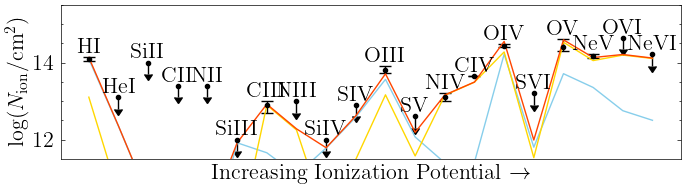

In [19]:
fig, ax = plt.subplots(1, figsize=(8,2))

plot_column_densities_obs(logN_dict, fig, ax)
ax.plot(np.arange(len(logN_dict)), logN_test_p1, color='skyblue')
ax.plot(np.arange(len(logN_dict)), logN_test_p2, color='gold')
ax.plot(np.arange(len(logN_dict)), logN_test, color='orangered')

ax.set_ylim(11.5,15.5)

In [20]:
pos = np.array([log_metals_test_p1,log_hdens_test_p1,logT_test_p1,C_O_test_p1,N_O_test_p1, 
                log_metals_test_p2,log_hdens_test_p2,logT_test_p2,C_O_test_p2,N_O_test_p2,logN_HI_test_p2]) + 1e-4 * np.random.randn(200, 11)
nwalkers, ndim = pos.shape

In [21]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability_3, args=(logN_dict,logX_dict_TDP_interp)
)

In [22]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [13:55<00:00,  1.67s/it]


In [23]:
flat_samples_3 = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_metals_p1','log_hdens_p1','logT_p1','C_O_p1','N_O_p1',
                                         'log_metals_p2','log_hdens_p2','logT_p2','C_O_p2','N_O_p2','logN_HI_p2'])
flat_samples_3.to_csv(savedir+'TDP.csv', index=False)

#flat_samples_3 = pd.read_csv(savedir+'TDP.csv')

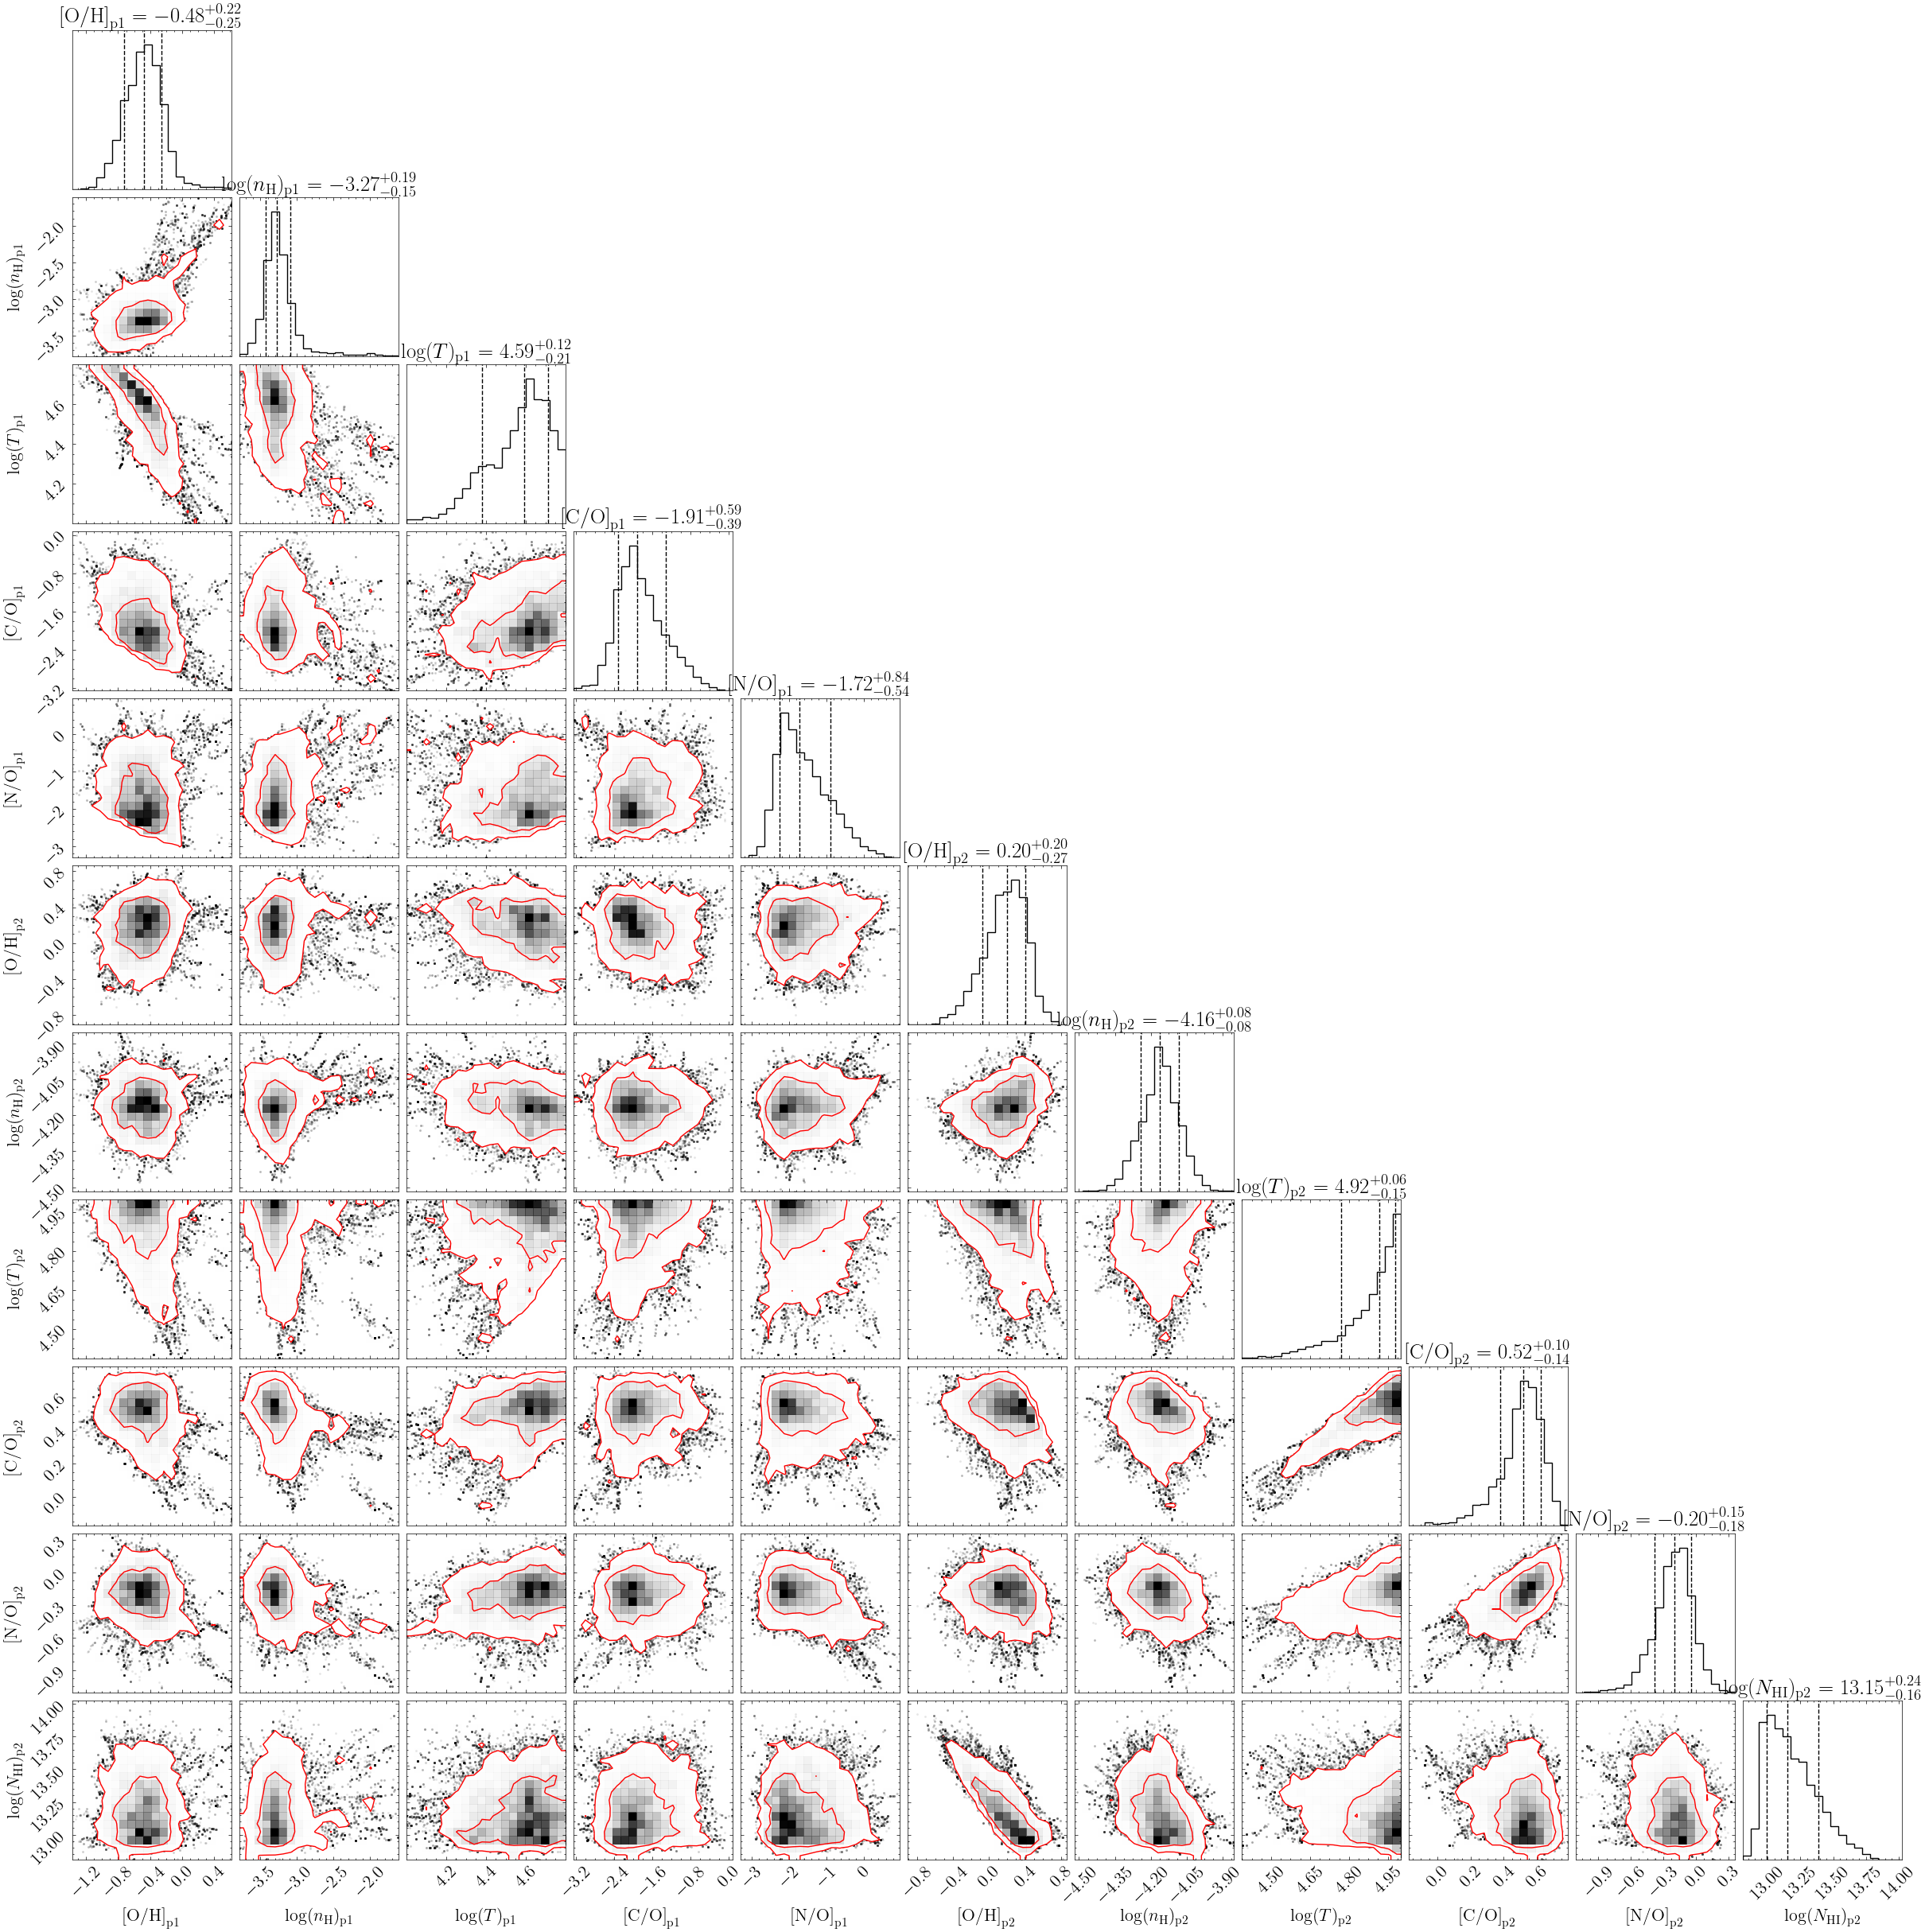

In [24]:
fig = corner.corner(
    flat_samples_3, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\mathrm{[O/H]}_\mathrm{p1}$',r'$\log(n_\mathrm{H})_\mathrm{p1}$',r'$\log(T)_\mathrm{p1}$',r'$\mathrm{[C/O]}_\mathrm{p1}$',r'$\mathrm{[N/O]}_\mathrm{p1}$',
            r'$\mathrm{[O/H]}_\mathrm{p2}$',r'$\log(n_\mathrm{H})_\mathrm{p2}$',r'$\log(T)_\mathrm{p2}$',r'$\mathrm{[C/O]}_\mathrm{p2}$',r'$\mathrm{[N/O]}_\mathrm{p2}$',
            r'$\log(N_\mathrm{HI})_\mathrm{p2}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [25]:
np.percentile(flat_samples_3['logT_p1'], 100*cdf_3sig), np.percentile(flat_samples_3['logT_p2'], 100*cdf_3sig)

(4.799530156455956, 4.999888711940069)

In [26]:
np.percentile(flat_samples_3['C_O_p1'], 100*cdf_3sig), np.percentile(flat_samples_3['N_O_p1'], 100*cdf_3sig)

(-0.2638021553353231, 0.5383080929927969)

Make a plot

In [27]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            'HeI':'<13.1',
            #'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.4',
            'NIII':'<13.0',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.81, -0.09, +0.09',
            'OIV':'14.44, -0.04, +0.04',
            'OV':'14.4, -0.1, +0.2',
            'OVI':'14.64, -0.07, +0.09',
            'NeV':'14.17, -0.05, +0.05',
            'NeVI':'14.22, -0.05, +0.05',
            #'NeVIII':'<13.6'
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            #'SiII':'<14.0',
            'SiIII':'<12.0',
            'SiIV':'<12.0',
            'SIV':'<12.9',
            'SV':'<12.6',
            'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [28]:
b_dict = {'HI':'24, -2, +3',
          'CIII':'11.1, -0.2, +0.2',
          'CIV':'11.1, -0.2, +0.2',
          'NIV':'12, -4, +6',
          'OIII':'11.9, -0.9, +0.9',
          'OIV':'11.9, -0.9, +0.9',
          'OV':'17, -1, +1',
          'OVI':'17, -1, +1',
          'NeV':'21, -3, +4',
          'NeVI':'21, -3, +4'}

In [29]:
p3_grid = np.array(flat_samples_3)

yb_med_p1 = np.zeros(len(logN_dict))
yb_lo_p1 = np.zeros(len(logN_dict))
yb_hi_p1 = np.zeros(len(logN_dict))

yb_med_p2 = np.zeros(len(logN_dict))
yb_lo_p2 = np.zeros(len(logN_dict))
yb_hi_p2 = np.zeros(len(logN_dict))

yb_med = np.zeros(len(logN_dict))
yb_lo = np.zeros(len(logN_dict))
yb_hi = np.zeros(len(logN_dict))

ctr = 0

for i in range(len(ion_species_dict)):
    
    ion = list(ion_species_dict.keys())[i]
    
    if ion in list(logN_dict.keys()):
        
        elem = ion_species_dict[ion].split('+')[0]

        y_samples_p1 = predict_col_dens_TDP(ion, p3_grid[:,0], p3_grid[:,1], p3_grid[:,2], 14.09, logX_dict_TDP_interp)
        y_samples_p2 = predict_col_dens_TDP(ion, p3_grid[:,5], p3_grid[:,6], p3_grid[:,7], p3_grid[:,10], logX_dict_TDP_interp)
        
        if elem == 'C':
            y_samples_p1 += p3_grid[:,3]
            y_samples_p2 += p3_grid[:,8]
            
        if elem == 'N':
            y_samples_p1 += p3_grid[:,4]
            y_samples_p2 += p3_grid[:,9]
            
        y_samples = np.log10(10**y_samples_p1 + 10**y_samples_p2) 
        
        yb_med_p1[ctr] = np.median(y_samples_p1)
        yb_lo_p1[ctr] = np.percentile(y_samples_p1, 16)
        yb_hi_p1[ctr] = np.percentile(y_samples_p1, 84)
        
        yb_med_p2[ctr] = np.median(y_samples_p2)
        yb_lo_p2[ctr] = np.percentile(y_samples_p2, 16)
        yb_hi_p2[ctr] = np.percentile(y_samples_p2, 84)
        
        yb_med[ctr] = np.median(y_samples)
        yb_lo[ctr] = np.percentile(y_samples, 16)
        yb_hi[ctr] = np.percentile(y_samples, 84)
        
        ctr += 1

In [30]:
import matplotlib.lines as mlines

In [31]:
z_sys = 1.27767328

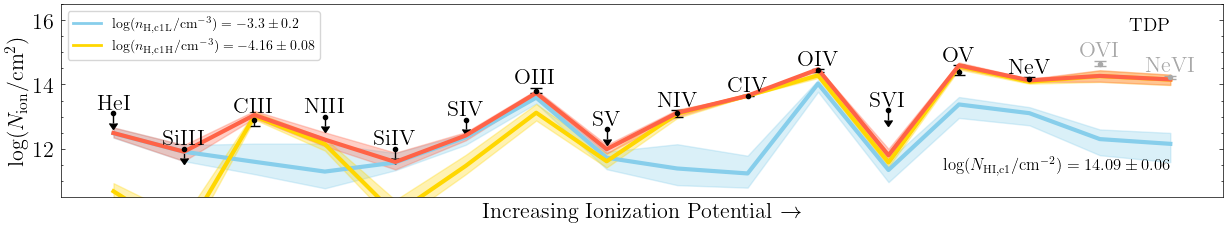

In [33]:
fig, ax = plt.subplots(1, figsize=(15,2.5))

plot_column_densities_obs(logN_dict, fig, ax,
                          gray_out = ['OVI', 'NeVI'])

ax.plot(np.arange(len(logN_dict)), yb_med_p1, lw=3, color='skyblue')
ax.fill_between(np.arange(len(logN_dict)), yb_lo_p1, yb_hi_p1, color='skyblue', alpha=.3)

ax.plot(np.arange(len(logN_dict)), yb_med_p2, lw=3, color='gold')
ax.fill_between(np.arange(len(logN_dict)), yb_lo_p2, yb_hi_p2, color='gold', alpha=.3)

ax.plot(np.arange(len(logN_dict)), yb_med, lw=3, color='tomato')
ax.fill_between(np.arange(len(logN_dict)), yb_lo, yb_hi, color='tomato', alpha=.3)

ax.set_ylim(10.5,16.5)

handles = []

handles.append(mlines.Line2D([], [], lw=2,
                             color='skyblue', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H, c1L}/\mathrm{cm}^{-3}) = -3.3 \pm 0.2$'))

handles.append(mlines.Line2D([], [], lw=2,
                             color='gold', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H, c1H}/\mathrm{cm}^{-3}) = -4.16 \pm 0.08$'))
    
ax.text(len(logN_dict)-1, 15.7, r'TDP',fontsize=14, horizontalalignment='right')
ax.text(len(logN_dict)-1, 11.3, r'$\log(N_\mathrm{HI, c1}/\mathrm{cm}^{-2}) = 14.09 \pm 0.06$', fontsize=12,
            horizontalalignment='right')

ax.legend(handles=handles, loc='upper left', fontsize=10)

plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_c1_TDP.pdf'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)
plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_c1_TDP.png'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)

In [34]:
logl_p1 = get_logl_TDP(p3_grid[:,0], p3_grid[:,1], p3_grid[:,2], 14.09, logX_dict_TDP_interp)
logl_p2 = get_logl_TDP(p3_grid[:,5], p3_grid[:,6], p3_grid[:,7], p3_grid[:,10], logX_dict_TDP_interp)

(array([5.1900e+02, 8.1600e+02, 1.2320e+03, 1.1210e+03, 2.1120e+03,
        1.4211e+04, 4.1083e+04, 1.7374e+04, 1.5280e+03, 4.0000e+00]),
 array([-3.61695109, -3.08942278, -2.56189447, -2.03436616, -1.50683785,
        -0.97930954, -0.45178123,  0.07574708,  0.60327539,  1.1308037 ,
         1.65833201]),
 <BarContainer object of 10 artists>)

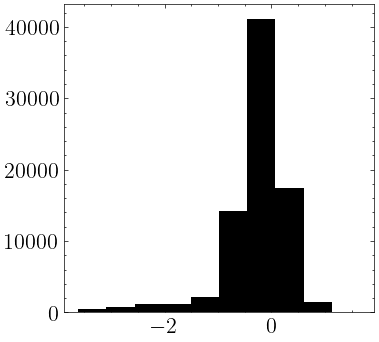

In [35]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logl_p1)

In [36]:
get_quantiles(logl_p1), np.percentile(logl_p1, 100*cdf_3sig)

-0.19 -0.4 0.38


(None, 0.8924941019101027)

(array([  312.,  2306.,  7290., 14074., 18086., 15926., 12051.,  6729.,
         2722.,   504.]),
 array([0.13786087, 0.32401025, 0.51015964, 0.69630902, 0.8824584 ,
        1.06860779, 1.25475717, 1.44090655, 1.62705594, 1.81320532,
        1.99935471]),
 <BarContainer object of 10 artists>)

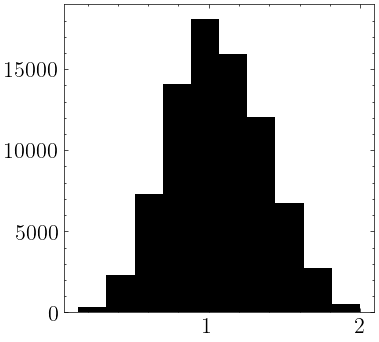

In [37]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logl_p2)

In [38]:
get_quantiles(logl_p2), np.percentile(logl_p2, 100*cdf_3sig)

1.05 -0.31 0.35


(None, 1.9216531510083215)